# 08 - Mixed Precision Policy

Notebook 07 asked which model components are fragile under targeted INT4 pressure.  This notebook asks the deployment question: given the measured GGUF payoff from Notebook 06 and the sensitivity evidence from Notebook 07, what mixed-precision policy would we actually recommend?

The output is a policy artifact, not a claim that a custom GGUF has already preserved HumanEval quality.  If local `llama.cpp` tooling supports targeted tensor precision, this notebook prepares a reproducible tensor-type manifest and optional build/benchmark path.  If the build or validation is not run, the limitation is recorded explicitly.

## 1. Goal

Inputs:
- Notebook 06 deployment evidence: artifact size, throughput, latency, and process RSS for FP16, Q8_0, and Q4_K_M GGUFs.
- Notebook 07 sensitivity evidence: full FP/BF16 baseline, 30-problem INT4 layer screen, and selected full HumanEval layer ablations.

Outputs:
- A compact evidence table connecting deployment payoff to layer sensitivity.
- Precision tiers for protected, lower-precision-candidate, and default layers.
- Two candidate policies: aggressive and conservative.
- A targeted GGUF export plan when the installed tooling supports it.
- `results/08_mixed_precision_policy.json` plus a tensor-type manifest for the recommended candidate.

## 2. Setup

In [19]:
from datetime import datetime, timezone
from pathlib import Path
from IPython.display import Markdown, display
import gc
import json
import math
import os
import re
import shutil
import statistics
import subprocess
import time

import matplotlib.pyplot as plt

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [20]:
CWD = Path.cwd().resolve()
if (CWD / "results").exists() and (CWD / "notebooks").exists():
    PROJECT_ROOT = CWD
else:
    PROJECT_ROOT = (CWD / "..").resolve()

RESULTS_DIR = PROJECT_ROOT / "results"
EXPORTS_DIR = PROJECT_ROOT / "exports"
RESULTS_DIR.mkdir(exist_ok=True)
EXPORTS_DIR.mkdir(exist_ok=True)

PERF06_PATH = RESULTS_DIR / "06_benchmarking_perf_snapshot.json"
BASELINE07_PATH = RESULTS_DIR / "07_full_baseline_humaneval.json"
SCREENING07_PATH = RESULTS_DIR / "07_layer_int4_screening_summary.json"
FOLLOWUP07_PATH = RESULTS_DIR / "07_selected_layer_int4_full_followup_runs.json"
LEGACY_LAYER0_FULL_PATH = RESULTS_DIR / "07_layer_00_all_linear_int4_ablation_summary.json"
PTQ05_PATH = RESULTS_DIR / "05_ptq_artifacts_summary.json"

POLICY_OUT_PATH = RESULTS_DIR / "08_mixed_precision_policy.json"
TENSOR_TYPES_PATH = RESULTS_DIR / "08_aggressive_q4_default_q8_protected_03_11_14_26.tensor_types.txt"
MIXED_ARTIFACT_PATH = EXPORTS_DIR / "DeepSeek-Coder-V2-Lite-Instruct-MIXED-Q4_K_M-protect-03-11-14-26-Q8_0.gguf"


def env_flag(name: str, default: bool) -> bool:
    raw = os.environ.get(name)
    if raw is None:
        return default
    return raw.strip().lower() in {"1", "true", "yes", "on"}


# Final handoff default: build or reuse the canonical mixed GGUF artifact.
# Notebook 09 performs the apples-to-apples quality and performance validation.
RUN_MIXED_DRY_RUN = env_flag("RUN_MIXED_DRY_RUN", True)
RUN_MIXED_EXPORT = True
RUN_MIXED_BENCHMARK = env_flag("RUN_MIXED_BENCHMARK", False)
ALLOW_REBUILD_EXISTING_MIXED_ARTIFACT = env_flag("ALLOW_REBUILD_EXISTING_MIXED_ARTIFACT", False)

# These come from Notebook 07's completed symmetric full-follow-up design.
PROTECTED_LAYERS = [3, 11, 14, 26]
LOWER_PRECISION_SEED_LAYERS = [0, 2, 15, 17]
RECOMMENDED_POLICY_ID = "aggressive_q4_k_m_default_q8_protected_layers_3_11_14_26"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Exports directory: {EXPORTS_DIR}")
print(f"Run mixed dry run: {RUN_MIXED_DRY_RUN}")
print(f"Run mixed export: {RUN_MIXED_EXPORT}")
print(f"Run mixed benchmark: {RUN_MIXED_BENCHMARK}")


Project root: /Users/jarrett/dev/quantization-study
Results directory: /Users/jarrett/dev/quantization-study/results
Exports directory: /Users/jarrett/dev/quantization-study/exports
Run mixed dry run: True
Run mixed export: True
Run mixed benchmark: False


In [21]:
def load_json(path: Path, required: bool = True):
    if path.exists():
        with path.open() as f:
            return json.load(f)
    if required:
        raise FileNotFoundError(f"Missing required artifact: {path}")
    return None


def save_json(path: Path, payload) -> None:
    with path.open("w") as f:
        json.dump(payload, f, indent=2)
    print(f"Saved {path}")


def markdown_table(rows, columns):
    if not rows:
        return "_No rows to display._"

    header = "| " + " | ".join(label for _, label in columns) + " |"
    divider = "| " + " | ".join("---" for _ in columns) + " |"
    body = []

    for row in rows:
        values = []
        for key, _ in columns:
            value = row.get(key, "")
            if value is None:
                value = ""
            elif isinstance(value, float):
                value = f"{value:.2f}"
            elif isinstance(value, list):
                value = ", ".join(str(v) for v in value)
            values.append(str(value))
        body.append("| " + " | ".join(values) + " |")

    return "\n".join([header, divider, *body])


def pct(numerator, denominator):
    if denominator in (None, 0) or numerator is None:
        return None
    return 100.0 * numerator / denominator


def safe_div(numerator, denominator):
    if denominator in (None, 0) or numerator is None:
        return None
    return numerator / denominator


def layer_list_text(layers):
    return ", ".join(str(layer) for layer in sorted(layers)) if layers else "none"


def tensor_type_name(tensor):
    value = tensor.tensor_type
    return value.name if hasattr(value, "name") else str(value)


def parse_quantize_dry_run(text: str):
    quant_match = re.search(r"quant size\s*=\s*([0-9.]+)\s*MiB\s*\(([0-9.]+)\s*BPW\)", text)
    fallback_match = re.search(r"WARNING:\s*(\d+)\s*of\s*(\d+)\s*tensor", text)
    return {
        "quant_size_mib": float(quant_match.group(1)) if quant_match else None,
        "bpw": float(quant_match.group(2)) if quant_match else None,
        "fallback_tensor_count": int(fallback_match.group(1)) if fallback_match else None,
        "fallback_tensor_total": int(fallback_match.group(2)) if fallback_match else None,
    }


def tail_lines(text: str, n: int = 18):
    lines = text.strip().splitlines()
    return "\n".join(lines[-n:])

In [22]:
perf06 = load_json(PERF06_PATH)
baseline07 = load_json(BASELINE07_PATH)
screening07 = load_json(SCREENING07_PATH)
followup07 = load_json(FOLLOWUP07_PATH)
legacy_layer0_full = load_json(LEGACY_LAYER0_FULL_PATH, required=False)
ptq05 = load_json(PTQ05_PATH, required=False)

artifact_rows = [
    {"artifact": PERF06_PATH.name, "present": PERF06_PATH.exists(), "role": "deployment payoff"},
    {"artifact": BASELINE07_PATH.name, "present": BASELINE07_PATH.exists(), "role": "full reference quality"},
    {"artifact": SCREENING07_PATH.name, "present": SCREENING07_PATH.exists(), "role": "layer screen"},
    {"artifact": FOLLOWUP07_PATH.name, "present": FOLLOWUP07_PATH.exists(), "role": "main full follow-up"},
    {"artifact": LEGACY_LAYER0_FULL_PATH.name, "present": LEGACY_LAYER0_FULL_PATH.exists(), "role": "legacy/context only"},
    {"artifact": PTQ05_PATH.name, "present": PTQ05_PATH.exists(), "role": "artifact compression summary"},
]

display(Markdown(markdown_table(artifact_rows, [
    ("artifact", "Artifact"),
    ("present", "Present"),
    ("role", "Role"),
])))


| Artifact | Present | Role |
| --- | --- | --- |
| 06_benchmarking_perf_snapshot.json | True | deployment payoff |
| 07_full_baseline_humaneval.json | True | full reference quality |
| 07_layer_int4_screening_summary.json | True | layer screen |
| 07_selected_layer_int4_full_followup_runs.json | True | main full follow-up |
| 07_layer_00_all_linear_int4_ablation_summary.json | True | legacy/context only |
| 05_ptq_artifacts_summary.json | True | artifact compression summary |

## 3. Deployment Payoff From Notebook 06

In [23]:
benchmark = perf06["benchmark_results"]
measurements = benchmark["measurements"]
artifacts = benchmark["artifacts"]
precision_order = ["fp16", "q8_0", "q4_k_m"]

fp16_perf = measurements["fp16"]["performance"]
fp16_latency = fp16_perf["total_latency_sec_mean"]
fp16_tps = fp16_perf["tokens_per_sec_mean"]
fp16_size = artifacts["fp16"]["artifact_size_gib"]
fp16_rss = measurements["fp16"]["memory"].get("peak_rss_gib")

deployment_rows = []
for precision in precision_order:
    measurement = measurements[precision]
    perf = measurement["performance"]
    memory = measurement["memory"]
    artifact = artifacts[precision]
    size = artifact["artifact_size_gib"]
    latency = perf["total_latency_sec_mean"]
    tps = perf["tokens_per_sec_mean"]
    rss = memory.get("peak_rss_gib")

    deployment_rows.append({
        "precision": precision,
        "label": artifact["label"],
        "size_gib": size,
        "size_vs_fp16_percent": pct(size, fp16_size),
        "tokens_per_sec": tps,
        "speedup_vs_fp16": safe_div(tps, fp16_tps),
        "latency_sec": latency,
        "latency_reduction_vs_fp16_percent": (1 - safe_div(latency, fp16_latency)) * 100 if safe_div(latency, fp16_latency) is not None else None,
        "peak_rss_gib": rss,
        "rss_vs_fp16_percent": pct(rss, fp16_rss),
    })

display(Markdown(markdown_table(deployment_rows, [
    ("label", "Precision"),
    ("size_gib", "Size GiB"),
    ("size_vs_fp16_percent", "Size vs FP16 %"),
    ("tokens_per_sec", "Tok/s"),
    ("speedup_vs_fp16", "Speedup"),
    ("latency_sec", "Latency s"),
    ("latency_reduction_vs_fp16_percent", "Latency reduction %"),
    ("peak_rss_gib", "Peak RSS GiB"),
])))

memory_notes = [
    note
    for measurement in measurements.values()
    for note in [measurement.get("memory", {}).get("measurement_note")]
    if note
]
if memory_notes:
    display(Markdown("Memory note: " + memory_notes[0]))

| Precision | Size GiB | Size vs FP16 % | Tok/s | Speedup | Latency s | Latency reduction % | Peak RSS GiB |
| --- | --- | --- | --- | --- | --- | --- | --- |
| FP16 (reference) | 29.27 | 100.00 | 75.31 | 1.00 | 1.76 | 0.00 | 29.51 |
| Q8_0 | 15.56 | 53.16 | 108.70 | 1.44 | 1.24 | 29.92 | 32.28 |
| Q4_K_M | 9.66 | 33.00 | 126.85 | 1.68 | 1.06 | 40.06 | 9.46 |

Memory note: Process RSS snapshot after the benchmark run; not isolated model memory.

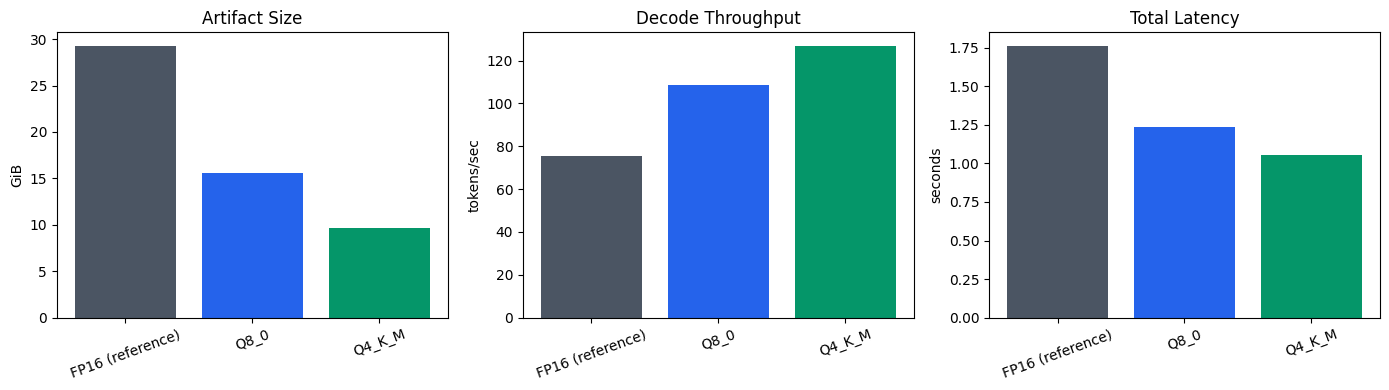

In [24]:
labels = [row["label"] for row in deployment_rows]
sizes = [row["size_gib"] for row in deployment_rows]
tps_values = [row["tokens_per_sec"] for row in deployment_rows]
latencies = [row["latency_sec"] for row in deployment_rows]
colors = ["#4b5563", "#2563eb", "#059669"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(labels, sizes, color=colors)
axes[0].set_title("Artifact Size")
axes[0].set_ylabel("GiB")

axes[1].bar(labels, tps_values, color=colors)
axes[1].set_title("Decode Throughput")
axes[1].set_ylabel("tokens/sec")

axes[2].bar(labels, latencies, color=colors)
axes[2].set_title("Total Latency")
axes[2].set_ylabel("seconds")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. Sensitivity Evidence From Notebook 07

Positive delta means the INT4 layer ablation hurt pass@1 relative to its reference run.  Negative delta means no observed harm in that run; it should not be interpreted as quantization improving quality.

In [25]:
full_baseline_eval = baseline07["evaluation"]
full_baseline_pass = full_baseline_eval["pass_at_1_percent"]
full_baseline_total = full_baseline_eval["n_total"]
full_baseline_passed = full_baseline_eval["n_passed"]

screen_reference = screening07["reference"]
screening_rows = screening07["summary_ranked_by_delta_desc"]
screen_by_layer = {row["layer_idx"]: row for row in screening_rows}

followup_selection = followup07.get("followup_selection", {})
sensitive_candidate_layers = sorted(followup_selection.get("sensitive_candidates", PROTECTED_LAYERS))
low_sensitivity_control_layers = sorted(followup_selection.get("low_sensitivity_controls", LOWER_PRECISION_SEED_LAYERS))
followup_is_complete = bool(followup07.get("is_complete", False))
followup_missing_layers = followup07.get("missing_layers", [])

full_followup_rows = []
for run in followup07.get("candidate_runs", []):
    candidate_pass = run["candidate_pass_at_1_percent"]
    layer_idx = run["layer_idx"]
    if layer_idx in sensitive_candidate_layers:
        group = "top-screened sensitive candidate"
        interpretation = "protect"
    elif layer_idx in low_sensitivity_control_layers:
        group = "bottom-screened low-sensitivity control"
        interpretation = "lower-precision candidate"
    else:
        group = "other full follow-up"
        interpretation = "review manually"

    full_followup_rows.append({
        "layer_idx": layer_idx,
        "group": group,
        "source": FOLLOWUP07_PATH.name,
        "reference_pass_at_1_percent": full_baseline_pass,
        "candidate_pass_at_1_percent": candidate_pass,
        "delta_pass_at_1_percent": full_baseline_pass - candidate_pass,
        "candidate_n_passed": run["candidate_n_passed"],
        "n_total": run["max_problems"],
        "n_modules": run["n_modules"],
        "interpretation": interpretation,
    })

full_by_layer = {row["layer_idx"]: row for row in full_followup_rows}

key_layer_order = sorted(
    sensitive_candidate_layers,
    key=lambda layer_idx: full_by_layer.get(layer_idx, {}).get("delta_pass_at_1_percent", 0),
    reverse=True,
) + sorted(
    low_sensitivity_control_layers,
    key=lambda layer_idx: full_by_layer.get(layer_idx, {}).get("delta_pass_at_1_percent", 0),
    reverse=True,
)

key_evidence_rows = []
for layer_idx in key_layer_order:
    screen_row = screen_by_layer.get(layer_idx)
    full_row = full_by_layer.get(layer_idx)
    key_evidence_rows.append({
        "layer_idx": layer_idx,
        "group": full_row["group"] if full_row else "selected follow-up",
        "screen_delta": screen_row["delta_pass_at_1_percent"] if screen_row else None,
        "screen_passed": f"{screen_row['candidate_n_passed']}/{screen_row['max_problems']}" if screen_row else "",
        "full_delta": full_row["delta_pass_at_1_percent"] if full_row else None,
        "full_passed": f"{full_row['candidate_n_passed']}/{full_row['n_total']}" if full_row else "not run",
        "evidence": "full follow-up" if full_row else "screen only",
        "interpretation": full_row["interpretation"] if full_row else "pending",
    })

sensitive_full_deltas = [full_by_layer[layer]["delta_pass_at_1_percent"] for layer in sensitive_candidate_layers if layer in full_by_layer]
control_full_deltas = [full_by_layer[layer]["delta_pass_at_1_percent"] for layer in low_sensitivity_control_layers if layer in full_by_layer]
sensitive_mean_delta = sum(sensitive_full_deltas) / len(sensitive_full_deltas) if sensitive_full_deltas else None
control_mean_delta = sum(control_full_deltas) / len(control_full_deltas) if control_full_deltas else None

baseline_line = (
    f"Notebook 07 full baseline: {full_baseline_passed}/{full_baseline_total} = "
    f"{full_baseline_pass:.2f}% pass@1. Full follow-up complete: {followup_is_complete}."
)
if followup_missing_layers:
    baseline_line += f" Missing layers: {followup_missing_layers}."

summary_line = (
    f"Mean full delta: protected candidates {sensitive_mean_delta:.2f} points; "
    f"low-sensitivity controls {control_mean_delta:.2f} points."
    if sensitive_mean_delta is not None and control_mean_delta is not None
    else "Mean full delta unavailable until both follow-up groups have completed runs."
)

display(Markdown(baseline_line + "\n\n" + summary_line + "\n\n" + markdown_table(key_evidence_rows, [
    ("layer_idx", "Layer"),
    ("group", "Group"),
    ("screen_delta", "Screen delta"),
    ("screen_passed", "Screen passed"),
    ("full_delta", "Full delta"),
    ("full_passed", "Full passed"),
    ("evidence", "Evidence"),
    ("interpretation", "Interpretation"),
])))


Notebook 07 full baseline: 115/164 = 70.12% pass@1. Full follow-up complete: True.

Mean full delta: protected candidates 13.11 points; low-sensitivity controls -3.51 points.

| Layer | Group | Screen delta | Screen passed | Full delta | Full passed | Evidence | Interpretation |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 26 | top-screened sensitive candidate | 43.33 | 11/30 | 22.56 | 78/164 | full follow-up | protect |
| 11 | top-screened sensitive candidate | 33.33 | 14/30 | 10.98 | 97/164 | full follow-up | protect |
| 14 | top-screened sensitive candidate | 23.33 | 17/30 | 10.37 | 98/164 | full follow-up | protect |
| 3 | top-screened sensitive candidate | 43.33 | 11/30 | 8.54 | 101/164 | full follow-up | protect |
| 0 | bottom-screened low-sensitivity control | -6.67 | 26/30 | -1.22 | 117/164 | full follow-up | lower-precision candidate |
| 15 | bottom-screened low-sensitivity control | -6.67 | 26/30 | -2.44 | 119/164 | full follow-up | lower-precision candidate |
| 17 | bottom-screened low-sensitivity control | -10.00 | 27/30 | -4.27 | 122/164 | full follow-up | lower-precision candidate |
| 2 | bottom-screened low-sensitivity control | -6.67 | 26/30 | -6.10 | 125/164 | full follow-up | lower-precision candidate |

In [26]:
top_screen_hits = sorted(screening_rows, key=lambda row: row["delta_pass_at_1_percent"], reverse=True)[:8]
low_or_negative_screen = sorted(
    [row for row in screening_rows if row["delta_pass_at_1_percent"] <= 0],
    key=lambda row: (row["delta_pass_at_1_percent"], row["layer_idx"]),
)

display(Markdown("### Top INT4 Screen Hits\n" + markdown_table(top_screen_hits, [
    ("layer_idx", "Layer"),
    ("candidate_pass_at_1_percent", "Candidate Pass@1"),
    ("delta_pass_at_1_percent", "Delta"),
    ("candidate_n_passed", "Passed"),
    ("max_problems", "Total"),
])))

display(Markdown("### Low Or Negative Screen Deltas\n" + markdown_table(low_or_negative_screen, [
    ("layer_idx", "Layer"),
    ("candidate_pass_at_1_percent", "Candidate Pass@1"),
    ("delta_pass_at_1_percent", "Delta"),
    ("candidate_n_passed", "Passed"),
    ("max_problems", "Total"),
])))

### Top INT4 Screen Hits
| Layer | Candidate Pass@1 | Delta | Passed | Total |
| --- | --- | --- | --- | --- |
| 3 | 36.67 | 43.33 | 11 | 30 |
| 26 | 36.67 | 43.33 | 11 | 30 |
| 11 | 46.67 | 33.33 | 14 | 30 |
| 14 | 56.67 | 23.33 | 17 | 30 |
| 1 | 60.00 | 20.00 | 18 | 30 |
| 8 | 60.00 | 20.00 | 18 | 30 |
| 10 | 60.00 | 20.00 | 18 | 30 |
| 6 | 63.33 | 16.67 | 19 | 30 |

### Low Or Negative Screen Deltas
| Layer | Candidate Pass@1 | Delta | Passed | Total |
| --- | --- | --- | --- | --- |
| 17 | 90.00 | -10.00 | 27 | 30 |
| 0 | 86.67 | -6.67 | 26 | 30 |
| 2 | 86.67 | -6.67 | 26 | 30 |
| 15 | 86.67 | -6.67 | 26 | 30 |
| 19 | 86.67 | -6.67 | 26 | 30 |
| 20 | 86.67 | -6.67 | 26 | 30 |
| 21 | 86.67 | -6.67 | 26 | 30 |
| 23 | 86.67 | -6.67 | 26 | 30 |
| 5 | 83.33 | -3.33 | 25 | 30 |
| 16 | 83.33 | -3.33 | 25 | 30 |
| 9 | 80.00 | 0.00 | 24 | 30 |

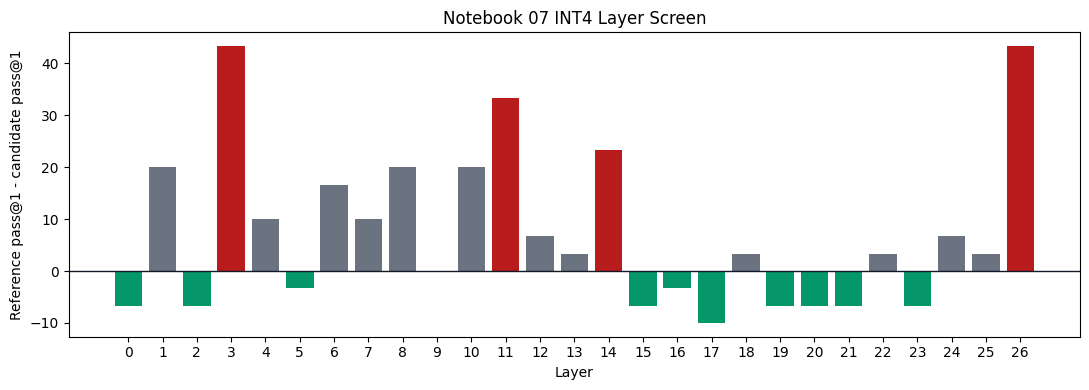

In [27]:
screen_by_index = sorted(screening_rows, key=lambda row: row["layer_idx"])
fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = []
for row in screen_by_index:
    layer_idx = row["layer_idx"]
    if layer_idx in PROTECTED_LAYERS:
        bar_colors.append("#b91c1c")
    elif layer_idx in LOWER_PRECISION_SEED_LAYERS or row["delta_pass_at_1_percent"] <= 0:
        bar_colors.append("#059669")
    else:
        bar_colors.append("#6b7280")

ax.bar(
    [row["layer_idx"] for row in screen_by_index],
    [row["delta_pass_at_1_percent"] for row in screen_by_index],
    color=bar_colors,
)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Notebook 07 INT4 Layer Screen")
ax.set_xlabel("Layer")
ax.set_ylabel("Reference pass@1 - candidate pass@1")
ax.set_xticks([row["layer_idx"] for row in screen_by_index])
plt.tight_layout()
plt.show()

## 5. Precision Tiers

In [28]:
all_screen_layers = sorted(screen_by_layer)
protected_layers_from_full_followup = sorted(
    row["layer_idx"] for row in full_followup_rows if row["interpretation"] == "protect"
)
lower_precision_candidate_layers = sorted(
    row["layer_idx"] for row in full_followup_rows if row["interpretation"] == "lower-precision candidate"
)

# Keep lower-precision candidates synchronized with Notebook 07 full follow-up.
# Protected layers are a deliberate Notebook 08 policy choice for this iteration.
LOWER_PRECISION_SEED_LAYERS = lower_precision_candidate_layers

default_layers = sorted(set(all_screen_layers) - set(PROTECTED_LAYERS) - set(lower_precision_candidate_layers))

precision_tiers = {
    "keep_higher_precision": {
        "layers": PROTECTED_LAYERS,
        "recommended_precision": "Q8_0 minimum in GGUF candidate; consider FP16 for final quality-risk validation",
        "rationale": "All four top-screened sensitive candidates now have full HumanEval INT4 follow-up drops.",
        "confidence": "high within the Notebook 07 PyTorch ablation methodology",
    },
    "candidate_lower_precision": {
        "layers": lower_precision_candidate_layers,
        "recommended_precision": "Q4_K_M in aggressive policy; Q4_K_M only for these layers in conservative policy",
        "rationale": "All four bottom-screened control layers had no observed full-run harm under targeted INT4 ablation. Negative deltas are treated as no-harm evidence, not quality improvement.",
        "confidence": "medium-high within the Notebook 07 PyTorch ablation methodology",
    },
    "policy_dependent_default": {
        "layers": default_layers,
        "recommended_precision": "Q4_K_M for memory/throughput target, Q8_0 for quality-risk target",
        "rationale": "These layers were screened but did not receive full HumanEval follow-up in Notebook 07.",
        "confidence": "medium for deployment-default use; low for per-layer sensitivity claims",
    },
}

tier_rows = [
    {
        "tier": "Keep higher precision",
        "layers": layer_list_text(precision_tiers["keep_higher_precision"]["layers"]),
        "precision": precision_tiers["keep_higher_precision"]["recommended_precision"],
        "confidence": precision_tiers["keep_higher_precision"]["confidence"],
    },
    {
        "tier": "Candidate lower precision",
        "layers": layer_list_text(precision_tiers["candidate_lower_precision"]["layers"]),
        "precision": precision_tiers["candidate_lower_precision"]["recommended_precision"],
        "confidence": precision_tiers["candidate_lower_precision"]["confidence"],
    },
    {
        "tier": "Policy-dependent default",
        "layers": layer_list_text(precision_tiers["policy_dependent_default"]["layers"]),
        "precision": precision_tiers["policy_dependent_default"]["recommended_precision"],
        "confidence": precision_tiers["policy_dependent_default"]["confidence"],
    },
]

display(Markdown(markdown_table(tier_rows, [
    ("tier", "Tier"),
    ("layers", "Layers"),
    ("precision", "Recommended precision"),
    ("confidence", "Confidence"),
])))


| Tier | Layers | Recommended precision | Confidence |
| --- | --- | --- | --- |
| Keep higher precision | 3, 11, 14, 26 | Q8_0 minimum in GGUF candidate; consider FP16 for final quality-risk validation | high within the Notebook 07 PyTorch ablation methodology |
| Candidate lower precision | 0, 2, 15, 17 | Q4_K_M in aggressive policy; Q4_K_M only for these layers in conservative policy | medium-high within the Notebook 07 PyTorch ablation methodology |
| Policy-dependent default | 1, 4, 5, 6, 7, 8, 9, 10, 12, 13, 16, 18, 19, 20, 21, 22, 23, 24, 25 | Q4_K_M for memory/throughput target, Q8_0 for quality-risk target | medium for deployment-default use; low for per-layer sensitivity claims |

In [29]:
candidate_policies = [
    {
        "policy_id": RECOMMENDED_POLICY_ID,
        "label": "Aggressive",
        "default_precision": "Q4_K_M",
        "protected_layers": PROTECTED_LAYERS,
        "protected_precision": "Q8_0 for quantizable tensors; existing F32 tensors stay F32",
        "lower_precision_layers": lower_precision_candidate_layers,
        "expected_payoff": "Closest to Q4_K_M size/throughput while protecting every full-follow-up sensitive layer.",
        "quality_confidence": "medium-high as a candidate policy; requires mixed GGUF HumanEval validation before final deployment claims",
    },
    {
        "policy_id": "conservative_q8_default_q4_full_no_harm_layers_0_2_15_17",
        "label": "Conservative",
        "default_precision": "Q8_0",
        "protected_layers": PROTECTED_LAYERS,
        "protected_precision": "Q8_0 or FP16 for layers 3, 11, 14, and 26",
        "lower_precision_layers": lower_precision_candidate_layers,
        "expected_payoff": "Keeps most of the Q8_0 quality-risk posture while using Q4_K_M only where full follow-up found no observed harm.",
        "quality_confidence": "higher than aggressive, but with smaller size/speed payoff",
    },
]

policy_rows = [
    {
        "label": policy["label"],
        "default": policy["default_precision"],
        "protected": layer_list_text(policy["protected_layers"]),
        "protected_precision": policy["protected_precision"],
        "lower_layers": layer_list_text(policy["lower_precision_layers"]),
        "confidence": policy["quality_confidence"],
    }
    for policy in candidate_policies
]

display(Markdown(markdown_table(policy_rows, [
    ("label", "Policy"),
    ("default", "Default"),
    ("protected", "Protected layers"),
    ("protected_precision", "Protected precision"),
    ("lower_layers", "Lower-precision candidates"),
    ("confidence", "Confidence"),
])))


| Policy | Default | Protected layers | Protected precision | Lower-precision candidates | Confidence |
| --- | --- | --- | --- | --- | --- |
| Aggressive | Q4_K_M | 3, 11, 14, 26 | Q8_0 for quantizable tensors; existing F32 tensors stay F32 | 0, 2, 15, 17 | medium-high as a candidate policy; requires mixed GGUF HumanEval validation before final deployment claims |
| Conservative | Q8_0 | 3, 11, 14, 26 | Q8_0 or FP16 for layers 3, 11, 14, and 26 | 0, 2, 15, 17 | higher than aggressive, but with smaller size/speed payoff |

## 6. GGUF Tooling Check

The key tooling question is whether the local `llama.cpp` quantizer can assign precision by tensor.  A clean path needs `llama-quantize --tensor-type` or `--tensor-type-file` so the policy can be represented in the artifact itself rather than simulated after the fact.

In [30]:
llama_quantize_path = shutil.which("llama-quantize")
help_text = ""
help_returncode = None
if llama_quantize_path:
    help_result = subprocess.run(
        [llama_quantize_path, "--help"],
        capture_output=True,
        text=True,
        timeout=30,
    )
    help_text = (help_result.stdout or "") + (help_result.stderr or "")
    help_returncode = help_result.returncode

supports_tensor_type_file = "--tensor-type-file" in help_text
supports_tensor_type = "--tensor-type" in help_text

f16_source_path = Path(artifacts["fp16"]["artifact_path"])
tensor_type_entries = []
gguf_reader_status = "not checked"

try:
    from gguf import GGUFReader

    gguf_reader_status = "available"
    if f16_source_path.exists():
        reader = GGUFReader(str(f16_source_path))
        protected_prefixes = tuple(f"blk.{layer_idx}." for layer_idx in PROTECTED_LAYERS)
        for tensor in reader.tensors:
            name = tensor.name
            if not name.startswith(protected_prefixes):
                continue
            if tensor_type_name(tensor).lower() == "f32":
                continue
            if len(tensor.shape) <= 1:
                continue
            tensor_type_entries.append(f"{name}=q8_0")
except Exception as exc:
    gguf_reader_status = f"error: {type(exc).__name__}: {exc}"

tensor_type_entries = sorted(set(tensor_type_entries))
if tensor_type_entries:
    TENSOR_TYPES_PATH.write_text("\n".join(tensor_type_entries) + "\n")

tooling_assessment = {
    "llama_quantize_path": llama_quantize_path,
    "help_returncode": help_returncode,
    "supports_tensor_type": supports_tensor_type,
    "supports_tensor_type_file": supports_tensor_type_file,
    "gguf_reader_status": gguf_reader_status,
    "f16_source_path": str(f16_source_path),
    "f16_source_exists": f16_source_path.exists(),
    "tensor_type_file": str(TENSOR_TYPES_PATH),
    "tensor_type_entry_count": len(tensor_type_entries),
    "targeted_mixed_precision_supported": bool(
        llama_quantize_path
        and supports_tensor_type_file
        and f16_source_path.exists()
        and tensor_type_entries
    ),
}

display(Markdown(markdown_table([tooling_assessment], [
    ("llama_quantize_path", "llama-quantize"),
    ("supports_tensor_type", "--tensor-type"),
    ("supports_tensor_type_file", "--tensor-type-file"),
    ("gguf_reader_status", "GGUF reader"),
    ("f16_source_exists", "F16 source exists"),
    ("tensor_type_entry_count", "Tensor overrides"),
    ("targeted_mixed_precision_supported", "Targeted export path"),
])))

print(f"Tensor-type manifest: {TENSOR_TYPES_PATH}")
print(f"First entries: {tensor_type_entries[:5]}")

| llama-quantize | --tensor-type | --tensor-type-file | GGUF reader | F16 source exists | Tensor overrides | Targeted export path |
| --- | --- | --- | --- | --- | --- | --- |
| /opt/homebrew/bin/llama-quantize | True | True | available | True | 44 | True |

Tensor-type manifest: /Users/jarrett/dev/quantization-study/results/08_aggressive_q4_default_q8_protected_03_11_14_26.tensor_types.txt
First entries: ['blk.11.attn_k_b.weight=q8_0', 'blk.11.attn_kv_a_mqa.weight=q8_0', 'blk.11.attn_output.weight=q8_0', 'blk.11.attn_q.weight=q8_0', 'blk.11.attn_v_b.weight=q8_0']


In [31]:
dry_run_result = {
    "requested": RUN_MIXED_DRY_RUN,
    "status": "not_run",
    "command": None,
    "returncode": None,
    "quant_size_mib": None,
    "quant_size_gib": None,
    "bpw": None,
    "fallback_tensor_count": None,
    "fallback_tensor_total": None,
    "output_tail": None,
}

if RUN_MIXED_DRY_RUN and tooling_assessment["targeted_mixed_precision_supported"]:
    dry_run_cmd = [
        llama_quantize_path,
        "--dry-run",
        "--tensor-type-file",
        str(TENSOR_TYPES_PATH),
        str(f16_source_path),
        str(MIXED_ARTIFACT_PATH),
        "Q4_K_M",
    ]
    completed = subprocess.run(
        dry_run_cmd,
        capture_output=True,
        text=True,
        timeout=300,
    )
    combined_output = (completed.stdout or "") + (completed.stderr or "")
    parsed = parse_quantize_dry_run(combined_output)
    dry_run_result.update({
        "status": "complete" if completed.returncode == 0 else "failed",
        "command": dry_run_cmd,
        "returncode": completed.returncode,
        "quant_size_mib": parsed["quant_size_mib"],
        "quant_size_gib": safe_div(parsed["quant_size_mib"], 1024),
        "bpw": parsed["bpw"],
        "fallback_tensor_count": parsed["fallback_tensor_count"],
        "fallback_tensor_total": parsed["fallback_tensor_total"],
        "output_tail": tail_lines(combined_output),
    })
elif RUN_MIXED_DRY_RUN:
    dry_run_result["status"] = "skipped_no_targeted_export_path"
else:
    dry_run_result["status"] = "skipped_by_flag"

q4_size = artifacts["q4_k_m"]["artifact_size_gib"]
q8_size = artifacts["q8_0"]["artifact_size_gib"]
if dry_run_result["quant_size_gib"] is not None:
    dry_run_result["extra_gib_vs_q4_k_m"] = dry_run_result["quant_size_gib"] - q4_size
    dry_run_result["size_vs_fp16_percent"] = pct(dry_run_result["quant_size_gib"], fp16_size)
    dry_run_result["size_vs_q8_percent"] = pct(dry_run_result["quant_size_gib"], q8_size)
else:
    dry_run_result["extra_gib_vs_q4_k_m"] = None
    dry_run_result["size_vs_fp16_percent"] = None
    dry_run_result["size_vs_q8_percent"] = None

dry_run_table = [{
    "status": dry_run_result["status"],
    "quant_size_gib": dry_run_result["quant_size_gib"],
    "extra_gib_vs_q4_k_m": dry_run_result["extra_gib_vs_q4_k_m"],
    "size_vs_fp16_percent": dry_run_result["size_vs_fp16_percent"],
    "size_vs_q8_percent": dry_run_result["size_vs_q8_percent"],
    "bpw": dry_run_result["bpw"],
    "fallbacks": (
        f"{dry_run_result['fallback_tensor_count']}/{dry_run_result['fallback_tensor_total']}"
        if dry_run_result["fallback_tensor_count"] is not None else ""
    ),
}]

display(Markdown(markdown_table(dry_run_table, [
    ("status", "Dry-run status"),
    ("quant_size_gib", "Predicted size GiB"),
    ("extra_gib_vs_q4_k_m", "Extra vs Q4 GiB"),
    ("size_vs_fp16_percent", "Size vs FP16 %"),
    ("size_vs_q8_percent", "Size vs Q8 %"),
    ("bpw", "BPW"),
    ("fallbacks", "Fallback tensors"),
])))

if dry_run_result["output_tail"]:
    print(dry_run_result["output_tail"])

| Dry-run status | Predicted size GiB | Extra vs Q4 GiB | Size vs FP16 % | Size vs Q8 % | BPW | Fallback tensors |
| --- | --- | --- | --- | --- | --- | --- |
| complete | 10.46 | 0.80 | 35.73 | 67.21 | 5.72 | 46/404 |

[ 390/ 404] blk.26.attn_k_b.weight               - [   128,    512,     16,      1], type =    f16, size =     2.00 MiB ->     1.06 MiB (q8_0)
[ 391/ 404] blk.26.attn_kv_a_mqa.weight          - [  2048,    576,      1,      1], type =    f16, size =     2.25 MiB ->     1.20 MiB (q8_0)
[ 392/ 404] blk.26.attn_kv_a_norm.weight         - [   512,      1,      1,      1], type =    f32, size =    0.002 MiB
[ 393/ 404] blk.26.attn_norm.weight              - [  2048,      1,      1,      1], type =    f32, size =    0.008 MiB
[ 394/ 404] blk.26.attn_output.weight            - [  2048,   2048,      1,      1], type =    f16, size =     8.00 MiB ->     4.25 MiB (q8_0)
[ 395/ 404] blk.26.attn_q.weight                 - [  2048,   3072,      1,      1], type =    f16, size =    12.00 MiB ->     6.38 MiB (q8_0)
[ 396/ 404] blk.26.attn_v_b.weight               - [   512,    128,     16,      1], type =    f16, size =     2.00 MiB ->     1.06 MiB (q8_0)
[ 397/ 404] blk.26.ffn_down_exps.weight      

## 7. Build And Verify Canonical Mixed GGUF

This section writes or reuses the canonical mixed GGUF and verifies that the protected-layer matrix tensors are actually Q8_0. The small local benchmark remains off by default because Notebook 09 is the apples-to-apples validation notebook; this notebook only needs to prove that the candidate artifact exists and matches the policy manifest.

In [32]:
build_status = {
    "requested": RUN_MIXED_EXPORT,
    "status": "not_run",
    "artifact_path": str(MIXED_ARTIFACT_PATH),
    "artifact_exists_before": MIXED_ARTIFACT_PATH.exists(),
    "artifact_size_gib": None,
    "command": None,
    "returncode": None,
    "output_tail": None,
}

if MIXED_ARTIFACT_PATH.exists() and not ALLOW_REBUILD_EXISTING_MIXED_ARTIFACT:
    build_status["status"] = "existing_artifact_reused" if RUN_MIXED_EXPORT else "skipped_existing_artifact_present"
elif RUN_MIXED_EXPORT and tooling_assessment["targeted_mixed_precision_supported"]:
    build_cmd = [
        llama_quantize_path,
        "--tensor-type-file",
        str(TENSOR_TYPES_PATH),
        str(f16_source_path),
        str(MIXED_ARTIFACT_PATH),
        "Q4_K_M",
    ]
    completed = subprocess.run(
        build_cmd,
        capture_output=True,
        text=True,
        timeout=None,
    )
    combined_output = (completed.stdout or "") + (completed.stderr or "")
    build_status.update({
        "status": "complete" if completed.returncode == 0 else "failed",
        "command": build_cmd,
        "returncode": completed.returncode,
        "output_tail": tail_lines(combined_output),
    })
elif RUN_MIXED_EXPORT:
    build_status["status"] = "skipped_no_targeted_export_path"
else:
    build_status["status"] = "skipped_by_flag"

if MIXED_ARTIFACT_PATH.exists():
    build_status["artifact_size_gib"] = MIXED_ARTIFACT_PATH.stat().st_size / (1024 ** 3)

build_status["artifact_exists_after"] = MIXED_ARTIFACT_PATH.exists()

display(Markdown(markdown_table([build_status], [
    ("requested", "Requested"),
    ("status", "Status"),
    ("artifact_exists_before", "Exists before"),
    ("artifact_exists_after", "Exists after"),
    ("artifact_size_gib", "Size GiB"),
])))

if build_status["output_tail"]:
    print(build_status["output_tail"])

| Requested | Status | Exists before | Exists after | Size GiB |
| --- | --- | --- | --- | --- |
| True | existing_artifact_reused | True | True | 10.46 |

In [33]:
mixed_artifact_verification = {
    "artifact_path": str(MIXED_ARTIFACT_PATH),
    "artifact_exists": MIXED_ARTIFACT_PATH.exists(),
    "tensor_type_counts": {},
    "protected_layer_matrix_types": {},
    "protected_layer_non_q8_matrix_tensors": [],
    "status": "not_run",
}

if MIXED_ARTIFACT_PATH.exists():
    try:
        from gguf import GGUFReader

        reader = GGUFReader(str(MIXED_ARTIFACT_PATH))
        tensor_type_counts = {}
        protected_layer_matrix_types = {str(layer_idx): {} for layer_idx in PROTECTED_LAYERS}
        non_q8 = []

        for tensor in reader.tensors:
            type_name = tensor_type_name(tensor)
            tensor_type_counts[type_name] = tensor_type_counts.get(type_name, 0) + 1

            for layer_idx in PROTECTED_LAYERS:
                prefix = f"blk.{layer_idx}."
                if not tensor.name.startswith(prefix):
                    continue
                if len(tensor.shape) <= 1 or type_name == "F32":
                    continue
                protected_layer_matrix_types[str(layer_idx)][tensor.name] = type_name
                if type_name != "Q8_0":
                    non_q8.append({"layer_idx": layer_idx, "tensor": tensor.name, "type": type_name})

        mixed_artifact_verification.update({
            "tensor_type_counts": tensor_type_counts,
            "protected_layer_matrix_types": protected_layer_matrix_types,
            "protected_layer_non_q8_matrix_tensors": non_q8,
            "status": "complete" if not non_q8 else "mismatch",
        })
    except Exception as exc:
        mixed_artifact_verification["status"] = f"error: {type(exc).__name__}: {exc}"
else:
    mixed_artifact_verification["status"] = "skipped_missing_artifact"

verification_rows = [
    {
        "status": mixed_artifact_verification["status"],
        "artifact_exists": mixed_artifact_verification["artifact_exists"],
        "q8_tensors": mixed_artifact_verification["tensor_type_counts"].get("Q8_0"),
        "q4_tensors": mixed_artifact_verification["tensor_type_counts"].get("Q4_K"),
        "f32_tensors": mixed_artifact_verification["tensor_type_counts"].get("F32"),
        "protected_mismatches": len(mixed_artifact_verification["protected_layer_non_q8_matrix_tensors"]),
    }
]

display(Markdown(markdown_table(verification_rows, [
    ("status", "Verification"),
    ("artifact_exists", "Artifact exists"),
    ("q8_tensors", "Q8_0 tensors"),
    ("q4_tensors", "Q4_K tensors"),
    ("f32_tensors", "F32 tensors"),
    ("protected_mismatches", "Protected mismatches"),
])))

| Verification | Artifact exists | Q8_0 tensors | Q4_K tensors | F32 tensors | Protected mismatches |
| --- | --- | --- | --- | --- | --- |
| complete | True | 54 | 196 | 108 | 0 |

In [34]:
BENCH_PROMPTS = [
    "Write a Python function `is_prime(n:int) -> bool` with type hints and docstring.",
    "Implement `merge_intervals(intervals)` in Python and explain edge cases briefly.",
    "Given a list of integers, return the longest increasing subsequence length in Python.",
]
BENCH_N_ROUNDS = 2
BENCH_MAX_TOKENS = 128
BENCH_TEMPERATURE = 0.0


def count_tokens(llm, text: str) -> int:
    if not text:
        return 0
    return len(llm.tokenize(text.encode("utf-8"), add_bos=False))


def run_streamed_trial(llm, prompt: str, max_tokens: int = 128, temperature: float = 0.0):
    start = time.perf_counter()
    first_token_time = None
    generated_chunks = []

    stream = llm.create_completion(
        prompt=prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        stream=True,
    )

    for chunk in stream:
        piece = chunk["choices"][0]["text"]
        if piece and first_token_time is None:
            first_token_time = time.perf_counter()
        generated_chunks.append(piece)

    end = time.perf_counter()
    generated_text = "".join(generated_chunks)
    generated_tokens = count_tokens(llm, generated_text)

    ttft_sec = (first_token_time - start) if first_token_time is not None else None
    total_latency_sec = end - start
    decode_tokens_per_sec = (
        generated_tokens / (end - first_token_time)
        if first_token_time is not None and end > first_token_time and generated_tokens > 0
        else 0.0
    )

    return {
        "ttft_sec": ttft_sec,
        "total_latency_sec": total_latency_sec,
        "decode_tokens_per_sec": decode_tokens_per_sec,
        "generated_tokens": generated_tokens,
        "generated_preview": generated_text[:160],
    }


def summarize_trials(trials):
    ttfts = [trial["ttft_sec"] for trial in trials if trial["ttft_sec"] is not None]
    tps = [trial["decode_tokens_per_sec"] for trial in trials]
    latencies = [trial["total_latency_sec"] for trial in trials]
    return {
        "ttft_sec_mean": statistics.mean(ttfts) if ttfts else None,
        "ttft_sec_std": statistics.pstdev(ttfts) if len(ttfts) > 1 else 0.0 if ttfts else None,
        "tokens_per_sec_mean": statistics.mean(tps) if tps else None,
        "tokens_per_sec_std": statistics.pstdev(tps) if len(tps) > 1 else 0.0 if tps else None,
        "total_latency_sec_mean": statistics.mean(latencies) if latencies else None,
        "total_latency_sec_std": statistics.pstdev(latencies) if len(latencies) > 1 else 0.0 if latencies else None,
        "n_samples": len(trials),
    }


benchmark_status = {
    "requested": RUN_MIXED_BENCHMARK,
    "status": "not_run",
    "artifact_path": str(MIXED_ARTIFACT_PATH),
    "artifact_exists": MIXED_ARTIFACT_PATH.exists(),
    "summary": None,
    "trials": [],
    "notes": [],
}

if RUN_MIXED_BENCHMARK and MIXED_ARTIFACT_PATH.exists():
    from llama_cpp import Llama

    llm_mixed = Llama(
        model_path=str(MIXED_ARTIFACT_PATH),
        n_ctx=2048,
        n_threads=8,
        n_gpu_layers=-1,
        verbose=False,
    )

    _ = run_streamed_trial(
        llm=llm_mixed,
        prompt=BENCH_PROMPTS[0],
        max_tokens=32,
        temperature=BENCH_TEMPERATURE,
    )

    mixed_trials = []
    for round_idx in range(BENCH_N_ROUNDS):
        for prompt_idx, prompt in enumerate(BENCH_PROMPTS):
            trial = run_streamed_trial(
                llm=llm_mixed,
                prompt=prompt,
                max_tokens=BENCH_MAX_TOKENS,
                temperature=BENCH_TEMPERATURE,
            )
            trial["round"] = round_idx + 1
            trial["prompt_index"] = prompt_idx
            mixed_trials.append(trial)

    summary = summarize_trials(mixed_trials)
    benchmark_status.update({
        "status": "complete",
        "summary": summary,
        "trials": mixed_trials,
        "notes": [
            "Performance benchmark only; this is not a HumanEval quality validation.",
            f"n_ctx=2048, n_threads=8, n_gpu_layers=-1, max_tokens={BENCH_MAX_TOKENS}, prompts={len(BENCH_PROMPTS)}, rounds={BENCH_N_ROUNDS}",
        ],
    })
    del llm_mixed
    gc.collect()
elif RUN_MIXED_BENCHMARK:
    benchmark_status["status"] = "skipped_missing_artifact"
else:
    benchmark_status["status"] = "skipped_by_flag"

if benchmark_status["summary"]:
    display(Markdown(markdown_table([benchmark_status["summary"]], [
        ("n_samples", "Samples"),
        ("ttft_sec_mean", "TTFT s"),
        ("tokens_per_sec_mean", "Tok/s"),
        ("total_latency_sec_mean", "Latency s"),
    ])))
else:
    display(Markdown(markdown_table([benchmark_status], [
        ("requested", "Requested"),
        ("status", "Status"),
        ("artifact_exists", "Artifact exists"),
    ])))

| Requested | Status | Artifact exists |
| --- | --- | --- |
| False | skipped_by_flag | True |

## 8. Save Policy Artifact

In [35]:
policy_payload = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "08_mixed_precision",
    "source_artifacts": {
        "deployment_perf": str(PERF06_PATH),
        "baseline_quality": str(BASELINE07_PATH),
        "layer_screening": str(SCREENING07_PATH),
        "selected_full_followup": str(FOLLOWUP07_PATH),
        "legacy_layer0_full": str(LEGACY_LAYER0_FULL_PATH) if legacy_layer0_full else None,
        "ptq_summary": str(PTQ05_PATH) if ptq05 else None,
    },
    "deployment_payoff": deployment_rows,
    "sensitivity_evidence": {
        "full_baseline": full_baseline_eval,
        "followup_selection": followup_selection,
        "followup_is_complete": followup_is_complete,
        "followup_missing_layers": followup_missing_layers,
        "group_mean_deltas": {
            "protected_candidates": sensitive_mean_delta,
            "low_sensitivity_controls": control_mean_delta,
        },
        "key_layers": key_evidence_rows,
        "full_followup_rows": sorted(full_followup_rows, key=lambda row: row["layer_idx"]),
        "top_screen_hits": top_screen_hits,
        "low_or_negative_screen_layers": low_or_negative_screen,
    },
    "precision_tiers": precision_tiers,
    "candidate_policies": candidate_policies,
    "recommendation": {
        "recommended_policy_id": RECOMMENDED_POLICY_ID,
        "scope": "recommended candidate for targeted GGUF build and validation, not a completed quality claim",
        "protected_layers": PROTECTED_LAYERS,
        "protected_layers_with_full_followup": PROTECTED_LAYERS,
        "protected_layers_requiring_retest": [],
        "lower_precision_candidate_layers": lower_precision_candidate_layers,
        "lower_precision_candidate_layers_with_full_followup": lower_precision_candidate_layers,
        "default_layers": default_layers,
    },
    "tooling_assessment": tooling_assessment,
    "tensor_type_manifest": {
        "path": str(TENSOR_TYPES_PATH),
        "entries": tensor_type_entries,
        "entry_count": len(tensor_type_entries),
    },
    "mixed_artifact_plan": {
        "path": str(MIXED_ARTIFACT_PATH),
        "base_quantization": "Q4_K_M",
        "protected_tensor_precision": "q8_0",
        "dry_run": dry_run_result,
        "build": build_status,
        "verification": mixed_artifact_verification,
        "benchmark": benchmark_status,
    },
    "limitations": [
        "Notebook 07 layer ablations are simulated PyTorch INT4 component tests, not a completed mixed GGUF quality evaluation.",
        "Negative full deltas in the low-sensitivity control group are treated as no observed harm in this run, not evidence that INT4 improves quality.",
        "Layers outside the eight full follow-up layers retain lower per-layer confidence and are handled by policy default precision.",
        "Notebook 06 memory values are process RSS snapshots and may include co-resident model state.",
        "The mixed artifact must be built and run through at least the Notebook 06 performance harness plus a HumanEval quality pass before production claims.",
    ],
}

save_json(POLICY_OUT_PATH, policy_payload)


Saved /Users/jarrett/dev/quantization-study/results/08_mixed_precision_policy.json


## 9. Recommendation

In [36]:
q8_row = next(row for row in deployment_rows if row["precision"] == "q8_0")
q4_row = next(row for row in deployment_rows if row["precision"] == "q4_k_m")
protected_rows = [full_by_layer[layer_idx] for layer_idx in PROTECTED_LAYERS]
lower_rows = [full_by_layer[layer_idx] for layer_idx in lower_precision_candidate_layers]

lines = [
    f"Deployment payoff: Q4_K_M is {q4_row['size_vs_fp16_percent']:.2f}% of FP16 size and measured {q4_row['speedup_vs_fp16']:.2f}x FP16 decode throughput in Notebook 06.",
    f"Q8_0 is {q8_row['size_vs_fp16_percent']:.2f}% of FP16 size and measured {q8_row['speedup_vs_fp16']:.2f}x FP16 decode throughput.",
    f"Sensitivity: the protected group {layer_list_text(PROTECTED_LAYERS)} had mean full INT4 delta {sensitive_mean_delta:.2f} points.",
    f"Sensitivity: the lower-precision candidate group {layer_list_text(lower_precision_candidate_layers)} had mean full INT4 delta {control_mean_delta:.2f} points, treated as no observed harm rather than quality improvement.",
]

for row in sorted(protected_rows, key=lambda item: item["delta_pass_at_1_percent"], reverse=True):
    lines.append(
        f"Protected layer {row['layer_idx']}: full delta {row['delta_pass_at_1_percent']:.2f} points "
        f"({row['candidate_n_passed']}/{row['n_total']} passed)."
    )

for row in sorted(lower_rows, key=lambda item: item["delta_pass_at_1_percent"]):
    lines.append(
        f"Lower-precision candidate layer {row['layer_idx']}: full delta {row['delta_pass_at_1_percent']:.2f} points "
        f"({row['candidate_n_passed']}/{row['n_total']} passed)."
    )

lines.extend([
    "Recommendation: build the aggressive candidate first - Q4_K_M default with Q8_0 overrides for quantizable tensors in layers 3, 11, 14, and 26 - because it protects every full-follow-up sensitive layer while preserving a Q4-like default.",
    "Confidence: medium-high for the policy design within the PyTorch ablation methodology; final deployment quality still requires mixed GGUF validation.",
])

if dry_run_result["quant_size_gib"] is not None:
    lines.append(
        f"Tooling dry-run: targeted export is available and predicts a mixed artifact around {dry_run_result['quant_size_gib']:.2f} GiB, "
        f"{dry_run_result['extra_gib_vs_q4_k_m']:.2f} GiB above the existing Q4_K_M artifact."
    )
else:
    lines.append("Tooling dry-run did not produce a size estimate; inspect the tooling assessment before attempting export.")

if build_status.get("artifact_exists_after"):
    lines.append(
        f"Mixed artifact: {Path(build_status['artifact_path']).name} exists at {build_status['artifact_size_gib']:.2f} GiB."
    )

if mixed_artifact_verification.get("status") == "complete":
    lines.append(
        f"Verification: all quantizable tensors in protected layers {layer_list_text(PROTECTED_LAYERS)} are Q8_0 in the mixed GGUF."
    )

if benchmark_status.get("summary"):
    summary = benchmark_status["summary"]
    lines.append(
        f"Mixed benchmark: {summary['tokens_per_sec_mean']:.2f} tok/s, "
        f"{summary['ttft_sec_mean']:.4f}s TTFT, {summary['total_latency_sec_mean']:.4f}s total latency over "
        f"{summary['n_samples']} samples."
    )

display(Markdown("\n".join(f"- {line}" for line in lines)))


- Deployment payoff: Q4_K_M is 33.00% of FP16 size and measured 1.68x FP16 decode throughput in Notebook 06.
- Q8_0 is 53.16% of FP16 size and measured 1.44x FP16 decode throughput.
- Sensitivity: the protected group 3, 11, 14, 26 had mean full INT4 delta 13.11 points.
- Sensitivity: the lower-precision candidate group 0, 2, 15, 17 had mean full INT4 delta -3.51 points, treated as no observed harm rather than quality improvement.
- Protected layer 26: full delta 22.56 points (78/164 passed).
- Protected layer 11: full delta 10.98 points (97/164 passed).
- Protected layer 14: full delta 10.37 points (98/164 passed).
- Protected layer 3: full delta 8.54 points (101/164 passed).
- Lower-precision candidate layer 2: full delta -6.10 points (125/164 passed).
- Lower-precision candidate layer 17: full delta -4.27 points (122/164 passed).
- Lower-precision candidate layer 15: full delta -2.44 points (119/164 passed).
- Lower-precision candidate layer 0: full delta -1.22 points (117/164 passed).
- Recommendation: build the aggressive candidate first - Q4_K_M default with Q8_0 overrides for quantizable tensors in layers 3, 11, 14, and 26 - because it protects every full-follow-up sensitive layer while preserving a Q4-like default.
- Confidence: medium-high for the policy design within the PyTorch ablation methodology; final deployment quality still requires mixed GGUF validation.
- Tooling dry-run: targeted export is available and predicts a mixed artifact around 10.46 GiB, 0.80 GiB above the existing Q4_K_M artifact.
- Mixed artifact: DeepSeek-Coder-V2-Lite-Instruct-MIXED-Q4_K_M-protect-03-11-14-26-Q8_0.gguf exists at 10.46 GiB.
- Verification: all quantizable tensors in protected layers 3, 11, 14, 26 are Q8_0 in the mixed GGUF.